# Notebook for practical exercises | Week #2 Lesson #1

## Introduction

This notebook contains practical hands-on exercises for the lesson about *Data Collection and Cleaning Techniques*.

After this session, you will know how to prepare a medical imaging dataset for training:
* Import and read medical images using Python ;
* Extract relevant radiomic features ;
* Split the dataset into train/valid/test ;
* Clean data: handle missing values, remove duplicates, normalize features.

## Dataset

In the following, we will use the [The Brain Resection Multimodal Imaging Database](https://www.cancerimagingarchive.net/collection/remind/) [1]. The Brain Resection Multimodal Imaging Database (ReMIND) contains pre- and intra-operative brain MRI collected on 114 consecutive patients who were surgically treated with image-guided tumor resection between 2018 and 2022.

[1] Juvekar, P., Dorent, R., Kögl, F., Torio, E., Barr, C., Rigolo, L., Galvin, C., Jowkar, N., Kazi, A., Haouchine, N., Cheema, H., Navab, N., Pieper, S., Wells, W. M., Bi, W. L., Golby, A., Frisken, S., & Kapur, T. (2023). The Brain Resection Multimodal Imaging Database (ReMIND) (Version 1) [dataset]. The Cancer Imaging Archive. [https://doi.org/10.7937/3RAG-D070](https://doi.org/10.7937/3RAG-D070)

In [1]:
import pydicom
import nrrd

import SimpleITK as sitk
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn import model_selection
from glob import glob
from radiomics import featureextractor

import sys 
sys.path.append('../../')
from utils.sitk_utils import load_dicom_series_to_3d_image, convert_np_to_sitk, reconstruct_mask_in_image_space

### Download 

Run the following cells to download and unzip the dataset. 

<div class="alert alert-block alert-danger">
<b>Replace the <code>DATA_PATH</code> with the path where you want to store the data folder. By default, it will be stored at the root of this repository.</b> <br>
<b>If you have already downloaded the dataset, comment the following cell by adding a <code>#</code> before the <code>!</code></b>
</div>

In [ ]:
DATA_PATH = '../..'

!curl https://uni-bonn.sciebo.de/s/s1t8QUZ02MF1Qoh/download --output {DATA_PATH}/data.zip
!unzip {DATA_PATH}/data.zip

### Metadata

In [5]:
# Load and observe available data
clinical_df = pd.read_csv(f'{DATA_PATH}/data/ReMIND/ReMIND_metadata.csv')
clinical_df.head() # Print the 5 fist rows of the dataframe

,Case Number,Age,Sex,Race,Ethnicity,Laterality,Previous Craniotomy,WHO Grade,Histopathology
0,1,41,Male,White,Not Hispanic,Right,No,3,Astrocytoma
1,2,22,Female,White,Not Hispanic,Right,No,2,Astrocytoma
2,3,30,Male,Asian,Not Hispanic,Left,No,2,Oligodendroglioma
3,4,23,Male,White,Hispanic,Left,No,1,Dysembryoplastic neuroepithelial tumor
4,5,27,Male,White,Not Hispanic,Right,No,Not assigned,Non-tumor epileptogenic brain parenchyma and g...


In [6]:
# Observe variables
clinical_df.columns

Index(['Case Number', 'Age', 'Sex', 'Race', 'Ethnicity', 'Laterality',
       'Previous Craniotomy', 'WHO Grade', 'Histopathology'],
      dtype='object')

We aim to train a model using pre-operative brain MRI scans to classify tumor grade (column **WHO Grade**). To do so, we need to make sure that the features we will be using are correct.

<div class="alert alert-block alert-info">
<b>Q1.</b> Observe the unique values in column <b>WHO Grade</b>, and identify issues that should be corrected.
</div>

In [7]:
clinical_df['WHO Grade'].unique() # To observe the different labels in this column

array(['3', '2', '1', 'Not assigned', '4'], dtype=object)

<div class="alert alert-block alert-success">
The column WHO Grade contains cells with value <b>Not assigned</b>. <br>
These samples could prevent us from correctly learning the mapping between features and target, thus, we need to remove it. 
</div>

The column contains `Not assigned` values. We need to drop the corresponding samples.

In [8]:
clinical_df = clinical_df.loc[clinical_df['WHO Grade']!='Not assigned'] # Correction

In [9]:
clinical_df['WHO Grade'].unique() # No more missing values

array(['3', '2', '1', '4'], dtype=object)

### Images

Now that we have a dataframe containing only samples that can be used for the classification, we need to find the corresponding image.
The column **Case Number** (sometimes also called **ID** in standard dataframes) provides a unique identifier for each patient. Now, our goal will be to link the images to their corresponding rows in the dataframes.

In [10]:
sorted(glob(f'{DATA_PATH}/data/ReMIND/*'))[0:5] # This command looks for folders within the dataset and displays the 5 first

['../../data/ReMIND/LICENSE',
 '../../data/ReMIND/ReMIND_metadata.csv',
 '../../data/ReMIND/sub-001',
 '../../data/ReMIND/sub-002',
 '../../data/ReMIND/sub-003']

In the dataset, each folder is named **ReMIND-XXX**, wich **XXX** representing the corresponding patient ID. Now, we will explore the content of a patient folder.

Folders are organized in the following way: 
```bash
sub-001/                     # Subject-level folder          
└── anat/                    # Structural MRI
    └── T1w/                 # T1w sequence
        ├── 1-001.dcm        # Images in DICOM format
        ├── 1-002.dcm
        ├── 1-003.dcm
        └── ...
└── seg/ 
```

In the following, we will focus on pre-operative T1 gadolinium enhanced MRI, which can be used to identify and locate tumors.
The images are located in a folder containing the label **3DAXT1postcontrast** for each patient.

Now, let's verify if we have an image for each patient in our dataframe. 

In [11]:
for patient in clinical_df['Case Number']:
    idx = str(patient).zfill(3)

    if len(glob(f'{DATA_PATH}/data/ReMIND/sub-{idx}/anat/T1w')) == 0:
        print('No T1w image for patient n.', idx)

No T1w image for patient n. 012
No T1w image for patient n. 032
No T1w image for patient n. 033
No T1w image for patient n. 040
No T1w image for patient n. 065
No T1w image for patient n. 087
No T1w image for patient n. 091
No T1w image for patient n. 096


Eight patients do not have pre-operative T1w images. We will thus have to remove them from the list when computing the features. 

Now, we will explore the structure of a DICOM file, and how we can read it with Python. 

In [12]:
t1w_file = glob(f'{DATA_PATH}/data/ReMIND/sub-001/anat/T1w/1-080.dcm')[0]
image = pydicom.dcmread(t1w_file)

The dcmread function from the pydicom library allows to read DICOM files and store their content in a Python object. Let's explore its different attributes. 

In [13]:
image

Dataset.file_meta -------------------------------
(0002, 0000) File Meta Information Group Length  UL: 204
(0002, 0001) File Meta Information Version       OB: b'\x00\x01'
(0002, 0002) Media Storage SOP Class UID         UI: MR Image Storage
(0002, 0003) Media Storage SOP Instance UID      UI: 1.3.6.1.4.1.14519.5.2.1.241234373646560912433565108058941598584
(0002, 0010) Transfer Syntax UID                 UI: Implicit VR Little Endian
(0002, 0012) Implementation Class UID            UI: 1.3.6.1.4.1.22213.1.143
(0002, 0013) Implementation Version Name         SH: '0.5'
(0002, 0016) Source Application Entity Title     AE: 'POSDA'
-------------------------------------------------
(0008, 0005) Specific Character Set              CS: 'ISO_IR 100'
(0008, 0008) Image Type                          CS: ['ORIGINAL', 'PRIMARY', 'MPR']
(0008, 0016) SOP Class UID                       UI: MR Image Storage
(0008, 0018) SOP Instance UID                    UI: 1.3.6.1.4.1.14519.5.2.1.241234373646560912

We can access DICOM headers' information using their name. For instance, to obtain the image type, run `image.ImageType`

<div class="alert alert-block alert-info">
<b>Q2.</b> Explore other informations contained in DICOM headers using similar commands.
</div>

In [14]:
image.ImageType

['ORIGINAL', 'PRIMARY', 'MPR']

<div class="alert alert-block alert-success">
You can access several attributes contained in the DICOM headers by typing <code>image.[ATTRIBUTE]</code>. <br>
<b>Tips to know the list of available attributes:</b> <br>
- Start by typing <code>image.</code> and press <code>TAB</code>. The list of available attributes will be displayed. <br>
- You can also use <code>help(image)</code>.
</div>

Now, we will try to better understand how the images are stored. We can see in the header that we have images of dimension 256 x 216 (see attributes `Rows` and `Columns`). In Python, this means that the image corresponds to an **array** with 256 rows and 216 columns, with each **cell** corresponding to the pixel intensity value. This array is stored in the attribute `pixel_array` of the image, and the `matplotlib` library allows to plot images stored as pixel intensity arrays.

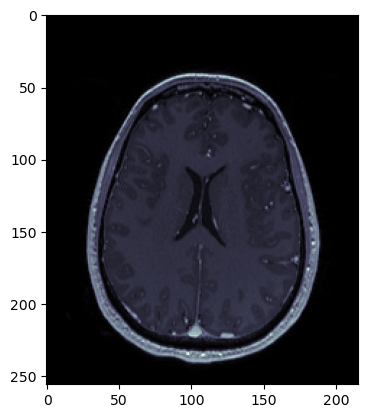

In [15]:
plt.imshow(image.pixel_array, cmap=plt.cm.bone)
plt.show()

Note that the images are 3D volumes, but DICOM files only contain slices. To load the full volume in a single array, we would have to loop over the slices and stack them to create a full volume. In practice, we will prefer to use `NIfTI` files (see practical session of Lesson 3 for more details).

In [16]:
# First use pre-defined function to load dicom series to 3D images, load mask and resample the mask to the image space
image_sitk = load_dicom_series_to_3d_image(
    glob(f'{DATA_PATH}/data/ReMIND/sub-001/anat/T1w')[0]) # !!! We use the path of the FOLDER, not the list of images 

[INFO] Loaded DICOM series with size: (216, 256, 192)


### Derivatives

The dataset we are using contains segmentation masks stored in **NRRD** format. These segmentation masked have been drawn manually by two neurosurgeons, and represent the boundaries of the tumor identified using the pre-operative MRI. In Lesson 3, we will see how you could generate these annotations by yourself.

Similarly to T1w images, we will verify that all patients have a pre-operative segmentation of the tumor region.

In [17]:
for patient in clinical_df['Case Number']:
    idx = str(patient).zfill(3)

    if len(glob(f'{DATA_PATH}/data/ReMIND/sub-{idx}/seg/ReMIND-{idx}-preop-SEG-tumor*.nrrd')) == 0:
        print('No pre-operative tumor segmentation for patient n.', idx)

No pre-operative tumor segmentation for patient n. 012
No pre-operative tumor segmentation for patient n. 032
No pre-operative tumor segmentation for patient n. 033
No pre-operative tumor segmentation for patient n. 040
No pre-operative tumor segmentation for patient n. 065
No pre-operative tumor segmentation for patient n. 087
No pre-operative tumor segmentation for patient n. 091
No pre-operative tumor segmentation for patient n. 096


To load NRRD files, we will use the `SimpleITK` package.

In [18]:
seg_file = glob(f'{DATA_PATH}/data/ReMIND/sub-001/seg/ReMIND-001-preop-SEG-tumor*.nrrd')[0]

reader = sitk.ImageFileReader() # Create a file reader
reader.SetImageIO("NrrdImageIO") # Set the input type
reader.SetFileName(seg_file) # Set the file name
mask_sitk = reader.Execute() # Load

<div class="alert alert-block alert-info">
<b>Q3.</b> Visualize the dimensions of the mask using the <code>GetSize()</code> function. What do you notice? How is this different from the DICOM image?
</div>

In [19]:
print('Mask shape:', mask_sitk.GetSize())
print('Image shape', image_sitk.GetSize())

Mask shape: (61, 63, 59)
Image shape (216, 256, 192)


<div class="alert alert-block alert-success">
Mask and Images have different shapes. This can happen when the mask comes from a <b>CROP</b> of the image. <br>
However, with SITK, we can access different attributes that allow us to reconstruct the mask in image space. <br>
These attributes are: <b>the origin in physical space, the space directions and the spacing.</b>
</div>

Now, we will reconstruct the mask in image space and visualize the results. 

In [20]:
mask_sitk_rec = reconstruct_mask_in_image_space(mask_sitk, image_sitk)

[INFO] Loaded mask with size: (61, 63, 59)


In [21]:
# Verify that the shape has been corrected
print('Mask shape:', mask_sitk_rec.GetSize())
print('Image shape', image_sitk.GetSize())

Mask shape: (216, 256, 192)
Image shape (216, 256, 192)


In [22]:
image_slice = sitk.GetArrayFromImage(image_sitk)[110]
mask_slice = sitk.GetArrayFromImage(mask_sitk_rec)[110]

<div class="alert alert-block alert-info">
<b>Q4.</b> Use the same function as below to plot the image, the mask and visualize their content.
</div>

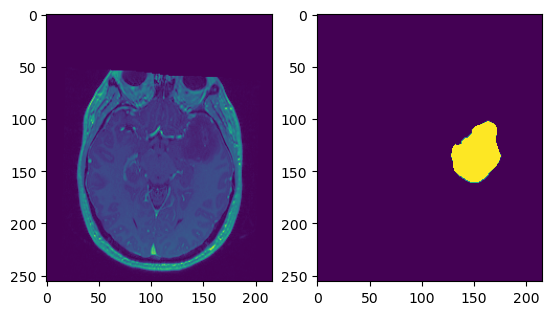

In [23]:
f, ax = plt.subplots(1,2)
ax[0].imshow(image_slice)
ax[1].imshow(mask_slice)
plt.show()

As you might have noticed, the function to read the file contains several attributes. The header contains information about the image: 
* size ;
* space directions ;
* origin ;
* ...

In [24]:
print('Origin:', image_sitk.GetOrigin()) # Origin in physical space
print('Dimensions:', image_sitk.GetSize()) # Shape
print('Directions:', image_sitk.GetDirection()) # Affine matrix

Origin: (150.248, -123.123, 68.3235)
Dimensions: (216, 256, 192)
Directions: (-0.7521951128278977, -0.6489012317876394, -0.1145849188257806, -0.6521878409159783, 0.7579752707489061, -0.011158364328042998, 0.09409321122791484, 0.06633762369581139, -0.9933507876290288)


## Feature extraction

Now that we observed the different data, we will extract radiomic features and visualize these features. 
To do so, we will use `SimpleITK` to load images, and `pyradiomics` to extract features. The idea is that, given an image and a corresponding mask, the code will extract relevant metrics. 

A detailed description of each metrics is available at [https://pyradiomics.readthedocs.io/en/latest/features.html](https://pyradiomics.readthedocs.io/en/latest/features.html).

We will now create the feature extractor and apply it to **the previously reconstructed image-mask pair**. 
We can define specific parameters for the feature extraction. In our case, we will add a **standard normalization space**, aiming mitigate pixel intensity differences across MRI machines.

In [25]:
settings = {}

# Normalizes the image by centering it at the mean with standard deviation. 
# Normalization is based on all gray values in the image, not just those inside the segmentation.
settings['normalize'] = True

# Create the featureextractor
extractor = featureextractor.RadiomicsFeatureExtractor(**settings)

In [26]:
# Extract features
result = extractor.execute(image_sitk, mask_sitk_rec)

GLCM is symmetrical, therefore Sum Average = 2 * Joint Average, only 1 needs to be calculated


In [27]:
result

OrderedDict([('diagnostics_Versions_PyRadiomics', 'v3.0.1'),
             ('diagnostics_Versions_Numpy', '1.24.4'),
             ('diagnostics_Versions_SimpleITK', '2.4.0'),
             ('diagnostics_Versions_PyWavelet', '1.4.1'),
             ('diagnostics_Versions_Python', '3.8.20'),
             ('diagnostics_Configuration_Settings',
              {'minimumROIDimensions': 2,
               'minimumROISize': None,
               'normalize': True,
               'normalizeScale': 1,
               'removeOutliers': None,
               'resampledPixelSpacing': None,
               'interpolator': 'sitkBSpline',
               'preCrop': False,
               'padDistance': 5,
               'distances': [1],
               'force2D': False,
               'force2Ddimension': 0,
               'resegmentRange': None,
               'label': 1,
               'additionalInfo': True}),
             ('diagnostics_Configuration_EnabledImageTypes', {'Original': {}}),
             ('diagno

<div class="alert alert-block alert-info">
<b>Q5.</b> Analyse the extracted features. Identify potential attributes that could be useful to classify the tumor grade. 
</div>

In [28]:
result['original_shape_VoxelVolume'] # example: tumor voxel volume, uniformity, etc.

75844.94136532053

In [29]:
result['original_glcm_JointEntropy']

array(0.78419256)

<div class="alert alert-block alert-info">
<b>Q6.</b> Implement and run the feature extraction without normalization and compare the results. 
</div>

In [30]:
# Without normalization
settings = {}

# Normalizes the image by centering it at the mean with standard deviation. 
# Normalization is based on all gray values in the image, not just those inside the segmentation.
settings['normalize'] = False

# Create the featureextractor
extractor = featureextractor.RadiomicsFeatureExtractor(**settings)
result_nn = extractor.execute(image_sitk, mask_sitk_rec)
result_nn

GLCM is symmetrical, therefore Sum Average = 2 * Joint Average, only 1 needs to be calculated


OrderedDict([('diagnostics_Versions_PyRadiomics', 'v3.0.1'),
             ('diagnostics_Versions_Numpy', '1.24.4'),
             ('diagnostics_Versions_SimpleITK', '2.4.0'),
             ('diagnostics_Versions_PyWavelet', '1.4.1'),
             ('diagnostics_Versions_Python', '3.8.20'),
             ('diagnostics_Configuration_Settings',
              {'minimumROIDimensions': 2,
               'minimumROISize': None,
               'normalize': False,
               'normalizeScale': 1,
               'removeOutliers': None,
               'resampledPixelSpacing': None,
               'interpolator': 'sitkBSpline',
               'preCrop': False,
               'padDistance': 5,
               'distances': [1],
               'force2D': False,
               'force2Ddimension': 0,
               'resegmentRange': None,
               'label': 1,
               'additionalInfo': True}),
             ('diagnostics_Configuration_EnabledImageTypes', {'Original': {}}),
             ('diagn

<div class="alert alert-block alert-success">
Radiomics features associated with space and volume are the same. However, features based on voxel intensity values are changes. <br>
<b>Example:</b> the feature <code>original_firstorder_Median</code> is 314 without normalization vs. around 0.69 with normalization.
</div>

Now that we better understand how to extract radiomic features from DICOM files associated with tumor masks, we will apply this to the whole dataset and transform the results to a csv file. 

In [31]:
feature_list = []

# Loop over patients 
for patient, tumor in zip(clinical_df['Case Number'], clinical_df['WHO Grade']):
    # Use pre-defined function to load dicom series to 3D images, load mask and resample the mask to the image space
    idx = str(patient).zfill(3)
    print(idx)
    img_dirname = glob(f'{DATA_PATH}/data/ReMIND/sub-{idx}/anat/T1w')
    seg_fname = glob(
        f'{DATA_PATH}/data/ReMIND/sub-{idx}/seg/ReMIND-{idx}-preop-SEG-tumor-*.nrrd')

    if len(img_dirname) == 0 or len(seg_fname)==0:
        continue # Allows to skip subjects without image or without segmentation
        
    image_sitk = load_dicom_series_to_3d_image(img_dirname[0])
    reader = sitk.ImageFileReader() # Create a file reader
    reader.SetImageIO("NrrdImageIO") # Set the input type
    reader.SetFileName(seg_fname[0]) # Set the file name
    mask_sitk = reader.Execute() # Load
    mask_sitk_rec = reconstruct_mask_in_image_space(mask_sitk, image_sitk) # Reconstruct in image space

    result = extractor.execute(image_sitk, mask_sitk_rec)

    result['patient'] = patient
    result['tumor'] = tumor
    
    feature_list.append(result)

001
[INFO] Loaded DICOM series with size: (216, 256, 192)
[INFO] Loaded mask with size: (61, 63, 59)


GLCM is symmetrical, therefore Sum Average = 2 * Joint Average, only 1 needs to be calculated

002
[INFO] Loaded DICOM series with size: (216, 256, 192)
[INFO] Loaded mask with size: (31, 47, 38)


GLCM is symmetrical, therefore Sum Average = 2 * Joint Average, only 1 needs to be calculated


003


...

112
[INFO] Loaded DICOM series with size: (224, 256, 192)
[INFO] Loaded mask with size: (48, 53, 51)


GLCM is symmetrical, therefore Sum Average = 2 * Joint Average, only 1 needs to be calculated

113
[INFO] Loaded DICOM series with size: (512, 512, 110)
[INFO] Loaded mask with size: (76, 110, 68)


GLCM is symmetrical, therefore Sum Average = 2 * Joint Average, only 1 needs to be calculated


114
[INFO] Loaded DICOM series with size: (224, 256, 192)
[INFO] Loaded mask with size: (54, 75, 42)


In [32]:
# Gather all radiomics data into a df
radiomics = pd.DataFrame()

for feature in feature_list:
  new_df = pd.DataFrame.from_dict(data=feature, orient='index')
  radiomics = pd.concat([radiomics, new_df.iloc[22:].T]) # Remove 22 first features which won't be useful (metadata)

radiomics.to_csv(f'{DATA_PATH}/data/ReMIND/radiomics.csv')

In [33]:
radiomics.head()

,original_shape_Elongation,original_shape_Flatness,original_shape_LeastAxisLength,original_shape_MajorAxisLength,original_shape_Maximum2DDiameterColumn,original_shape_Maximum2DDiameterRow,original_shape_Maximum2DDiameterSlice,original_shape_Maximum3DDiameter,original_shape_MeshVolume,original_shape_MinorAxisLength,...,original_glszm_ZoneEntropy,original_glszm_ZonePercentage,original_glszm_ZoneVariance,original_ngtdm_Busyness,original_ngtdm_Coarseness,original_ngtdm_Complexity,original_ngtdm_Contrast,original_ngtdm_Strength,patient,tumor
0,0.837068,0.729102,41.555383,56.995313,65.75327922546943,62.94624980721421,64.20109876152401,67.46173875265966,75786.25052172983,47.708958,...,7.13977806517449,0.14495341322033473,18449.80663276446,3.4423416583473414,0.00019116094308172998,6250.096857424745,0.029388346173303298,1.297054510456621,1,3
0,0.861722,0.608667,24.532541,40.305356,40.72563961972394,47.05289575553982,46.92583532510809,47.5208776161106,23657.64925141389,34.731995,...,6.449601270354517,0.056420781520383115,40135.20697200454,5.362219811992854,0.0005228313273453701,597.0778846989493,0.01402873996216244,0.6683653398080573,2,2
0,0.566089,0.382592,9.509478,24.855385,26.700362586774993,26.20627534148716,16.993597081732773,31.446899789863767,2249.2897325946974,14.070369,...,7.068037466232698,0.14634858812074003,1969.331392659347,0.26141935926235155,0.0010980106153590378,4524.609054427423,0.017783892505607083,5.028148359794059,3,2
0,0.908711,0.734795,12.352049,16.810202,19.849530684402417,19.235420568927154,18.027756728148727,20.736534670229933,2183.1438291485997,15.275615,...,5.6345882457332666,0.1453884597910041,1579.719521484375,1.6887797125113735,0.0034770640960660585,328.7360633056576,0.044171305911883806,1.0982787232655686,4,1
0,0.632528,0.389113,14.452207,37.14145,38.47153442183275,45.301701862125874,31.99197249749719,49.52153463896217,7101.510326143999,23.493002,...,7.883485477275589,0.28265215459795645,242.6014109872974,0.35321329164631177,0.00046837057160346195,25575.574160151613,0.04659586862716607,8.255818131110123,6,2


## Preprocess and clean

Now that we have extracted the radiomic features for all patients, we will process and clean the values. 

### Detect outliers

To identify outliers, several strategies are possible. 

#### Median Absolute Deviation
One of the most common is to use the MAD (Median Absolute Deviation) rule.
This statistical outlier detection method uses the median and the median absolute deviation as robust estimators to identify outliers in a dataset.

In [45]:
# Define the threshold multiplier and the radiomic value to inspect
threshold=5.0
outlier_col = 'original_shape_VoxelVolume'
  
# Calculate the median
median = np.median(radiomics[outlier_col])
    
# Calculate the absolute differences from the median
abs_diff = np.abs(radiomics[outlier_col] - median)

# Calculate the MAD (Median Absolute Deviation)
mad = np.median(abs_diff)

# Define the threshold for outliers
outlier_threshold = threshold * mad

# Identify outliers based on the threshold
outliers = [i for i, x in enumerate(radiomics[outlier_col]) if np.abs(x - median) > outlier_threshold]

In [46]:
print(outlier_threshold)

68530.8163055362


In [48]:
radiomics[outlier_col].iloc[outliers]

0    296691.379846
0     94799.163564
0     591389.08549
0    208322.525024
0     94868.638409
0    114567.834872
0    138798.699897
0    198578.659436
Name: original_shape_VoxelVolume, dtype: object

#### Interquartile Range

The 1.5 IQR (Interquartile Range) rule uses the IQR to identify outliers based on quartiles.

<div class="alert alert-block alert-info">
<b>Q7.</b> Complete the following code to check the results of this method compared to the MAD rule.
</div>

In [96]:
# Define the radiomic value to inspect
outlier_col = 'original_shape_VoxelVolume'

# Calculate the quantiles
q1 = np.quantile(a = radiomics[outlier_col], 
                 q = 0.25) # COMPLETE
q3 = np.quantile(a = radiomics[outlier_col], 
                 q = 0.75) # COMPLETE
    
# Calculate the interquartile range 
iqr = q3-q1 # COMPLETE

# Compute the lower and upper bounds
lower_bound = q1 - 1.5 * iqr
upper_bound = q3 + 1.5 * iqr

# Identify outliers based on the threshold
outliers = [i for i, x in enumerate(radiomics[outlier_col]) if x > upper_bound or x < lower_bound]

In [98]:
outliers

[21, 39, 43, 44, 52, 60, 66, 70]

In [97]:
radiomics[outlier_col].iloc[outliers] # We retrieve the same values as before

0    296691.379846
0     94799.163564
0     591389.08549
0    208322.525024
0     94868.638409
0    114567.834872
0    138798.699897
0    198578.659436
Name: original_shape_VoxelVolume, dtype: object

#### More advanced strategies

To detect outliers, we can use functions defined in `scikit-learn`.

The **Local Outlier Factor** measures the local deviation of the density of a given sample with respect to its neighbors. By comparing the local density of a sample to the local densities of its neighbors, one can identify samples that have a substantially lower density than their neighbors. These are considered outliers.

In [53]:
from sklearn.neighbors import LocalOutlierFactor

clf = LocalOutlierFactor(n_neighbors=20, contamination=0.1)
y_pred = clf.fit_predict(radiomics.drop(['tumor', 'patient'], axis=1)) # In this case, we can use all the features
n_errors = (y_pred != radiomics['tumor']).sum()
X_scores = clf.negative_outlier_factor_

In [61]:
X_scores

array([  -1.26884171,   -0.99871516,   -1.51009601,   -1.00087961,
         -2.59440533,  -20.8484698 ,   -1.29831492,   -2.53231542,
         -1.2292212 ,   -0.96804185,   -1.10249225,   -1.03991846,
         -1.0005659 ,   -1.00240348,   -0.99126546,   -1.180404  ,
         -1.11371241,   -1.0686085 ,   -1.03386774,  -12.26592943,
         -1.21976056,   -2.62567746,   -1.22977168,  -35.374721  ,
         -0.96840429,   -2.30951508,   -1.23490075,   -1.24930482,
         -1.00229386,   -1.00431291,   -1.2094142 ,   -1.25574043,
         -1.07738827,   -1.12142853,   -0.96693578,   -1.17518586,
         -1.0005659 ,   -1.36117555,   -1.09002278,   -1.55027955,
         -1.13466308,   -1.38946932,   -1.18294642, -100.82812342,
         -2.86402414,   -0.97421063,   -1.25269581,   -1.10513574,
         -1.27206121,   -1.27143341,   -1.31848169,   -0.96683266,
         -2.15073254,   -1.43806712,   -1.26616618,   -1.20246831,
         -1.16035807,   -1.24051721,   -1.02286352,   -1.00077

In [101]:
radiomics.reset_index().loc[X_scores < -3].index

Index([5, 19, 23, 43, 60, 66, 70, 84], dtype='int64')

We can see samples with relatively low outlier scores. In practice, we could decide to remove these outliers, as too many outliers could prevent to learn proper boundary decisions for classification. 

We can also notice that some samples have already been detected with other techniques based on a single column. Note that others were not detected, probably because the sample was not an outlier based on the other columns.

### Standardization

Different variables/features in a dataset have different range of value. To harmonize this, we usually use the **Z score**. 
By computing the Z scores of features, we can tell how many standard deviations away a data point is from the mean.

Z scoring can also be used for outlier detection. After Z scoring, features follow a Normal distribution with: 
* 68% of the data points lie between +/- 1 standard deviation
* 95% of the data points lie between +/- 2 standard deviation
* 99.7% of the data points lie between +/- 3 standard deviation

Z scoring can be applied directly on features using predefined functions from `scikit-learn`.

In [2]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler() # Create the scaler 
radiomics_zscore = scaler.fit_transform(radiomics.drop(['patient', 'tumor'], axis=1))
radiomics_zscore_df = pd.DataFrame(radiomics_zscore, columns=radiomics.columns[:-2])

radiomics_zscore_df

,original_shape_Elongation,original_shape_Flatness,original_shape_LeastAxisLength,original_shape_MajorAxisLength,original_shape_Maximum2DDiameterColumn,original_shape_Maximum2DDiameterRow,original_shape_Maximum2DDiameterSlice,original_shape_Maximum3DDiameter,original_shape_MeshVolume,original_shape_MinorAxisLength,...,original_glszm_SmallAreaHighGrayLevelEmphasis,original_glszm_SmallAreaLowGrayLevelEmphasis,original_glszm_ZoneEntropy,original_glszm_ZonePercentage,original_glszm_ZoneVariance,original_ngtdm_Busyness,original_ngtdm_Coarseness,original_ngtdm_Complexity,original_ngtdm_Contrast,original_ngtdm_Strength
0,0.860020,1.122862,1.396610,0.253136,0.830442,0.343751,0.356849,0.251977,0.471729,0.715953,...,-0.134040,-0.006542,0.587638,-0.229040,-0.301505,-0.181221,-0.331200,-0.111814,-0.408733,-0.158659
1,1.025073,0.507871,0.104606,-0.356884,-0.209951,-0.226259,-0.214213,-0.377701,-0.208317,0.018649,...,-0.173439,0.577784,-0.176907,-0.812217,-0.202383,-0.030719,-0.284125,-0.123831,-0.506981,-0.294942
2,-0.954156,-0.646563,-1.035618,-0.921583,-0.792979,-0.973916,-1.203671,-0.885273,-0.487601,-1.091582,...,-0.058062,-0.554663,0.508167,-0.219850,-0.376836,-0.430580,-0.202489,-0.115482,-0.482961,0.650141
3,1.339663,1.151933,-0.819872,-1.215635,-1.077766,-1.223924,-1.169485,-1.223477,-0.488464,-1.026820,...,-0.181980,0.602078,-1.079740,-0.226175,-0.378617,-0.318686,0.135175,-0.124402,-0.314173,-0.201749
4,-0.509357,-0.613268,-0.660474,-0.472525,-0.303654,-0.289065,-0.707875,-0.314526,-0.424301,-0.585267,...,0.000883,-0.556003,1.411481,0.678000,-0.384729,-0.423384,-0.291855,-0.070733,-0.298664,1.349813
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
81,0.307512,0.573204,0.431443,-0.133948,0.009611,0.039355,-0.226353,0.007675,-0.127282,0.033821,...,-0.151222,-0.407125,-0.290701,-0.640941,-0.129418,-0.139445,-0.320437,-0.122641,-0.532607,-0.271324
82,0.227292,0.801581,0.348201,-0.307988,0.051296,-0.205026,-0.459702,-0.337251,-0.210725,-0.186051,...,-0.166249,-0.338557,0.062217,-0.684588,-0.284010,-0.260855,-0.293322,-0.123544,-0.483313,-0.357541
83,0.753699,0.609459,0.675441,0.033831,0.316019,0.220132,0.079169,0.003267,0.041392,0.402556,...,-0.161249,-0.371981,0.496204,0.383430,-0.378423,0.069040,-0.320367,-0.121900,0.099304,-0.397565
84,-0.320868,-0.666170,0.510475,1.053418,2.009791,1.596961,0.038058,1.505980,0.488741,0.953067,...,0.272895,-0.584651,1.840182,1.904778,-0.385568,-0.334262,-0.348640,0.042336,0.637066,-0.172385


Now that we have z-scored data, we can use the thresholds explained above to detect outliers.

In [3]:
# Extreme values based on outlier columns.
radiomics_zscore_df[(radiomics_zscore_df[outlier_col]<-2) | (radiomics_zscore_df[outlier_col]>2)]

NameError: name 'outlier_col' is not defined

In [5]:
# Save our standardized measures 
radiomics_zscore_df['patient'] = radiomics['patient'].values
radiomics_zscore_df['tumor'] = radiomics['tumor'].values
radiomics_zscore_df.to_csv(f'{DATA_PATH}/data/ReMIND/radiomics_standardized.csv', index=False)